1377
Total dataset used: 1377

Torque Training Samples: 1101
Torque Testing Samples : 276

Training Torque Model...

Torque Performance
-------------------------
R2   : 0.999317750573199
MAE  : 0.41726318636023585
RMSE : 0.5685005426126395

BSFC Training Samples: 989
BSFC Testing Samples : 248

Training BSFC Model...

BSFC Performance
-------------------------
R2   : 0.9921351828121502
MAE  : 4.294260540696683
RMSE : 7.611876586476481

Cross Validation Scores


D:\Users\M19675A\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
D:\Users\M19675A\AppData\Local\anaconda3\Lib\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Torque CV R2: 0.9993679285403012
BSFC CV R2 : 0.9938000769111947


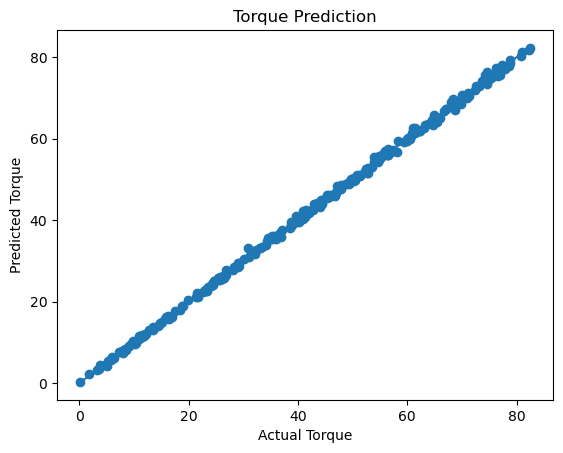

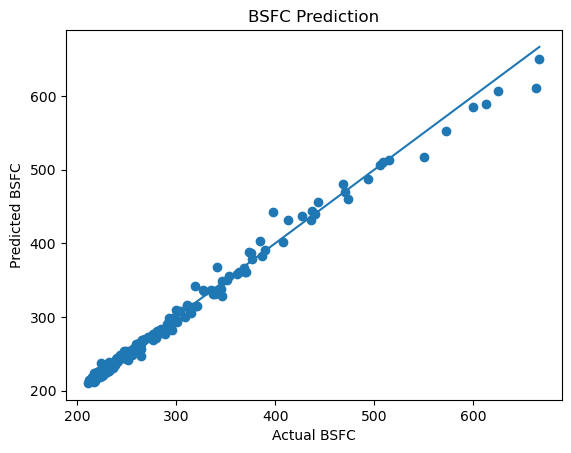

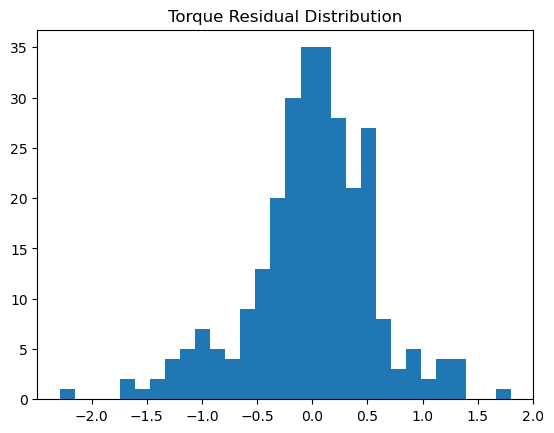

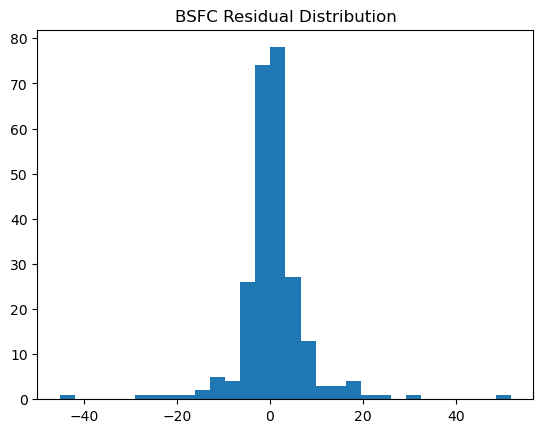

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_excel(r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\CNG_DATA_MODELING.xlsx")
# =====================================================
# VALID COMBUSTION FILTERS
# =====================================================
df = df[
    (df["MFB50_0"].between(6,25)) &
   (df["CIMEP1"].between(0,6))
]
df = df[
    (df["EM_THC_2"] <= 10000) &
   (df["EM_NOX_2"] <= 5000) &
   (df["EM_COH_2"] <= 20000)
]
print(len(df))

# ==========================================================
# CLEAN DATA
# ==========================================================
df = df.dropna(subset=[
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round",
    "TORQUE",
    "BSFC",
    "ADVOBJSS"
])

# ==========================================================
# SAMPLE DOE DATA
# ==========================================================
df = df.sample(len(df), random_state=42).reset_index(drop=True)

print("Total dataset used:", len(df))

# ==========================================================
# INPUT FEATURES
# ==========================================================
features = [
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round"
]

# ==========================================================
# KERNEL (OPTIMIZED + BOUNDED)
# ==========================================================
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * \
         RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e3)) + \
         WhiteKernel(noise_level=1, noise_level_bounds=(1e-5, 1e2))

# ==========================================================
# MODEL BUILDER FUNCTION
# ==========================================================
def build_gp():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("gp", GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=15,
            normalize_y=True,
            random_state=42
        ))
    ])

# ==========================================================
# ==========================================================
# TORQUE MODEL
# ==========================================================
# ==========================================================

X = df[features]
y_torque = df["TORQUE"]

X_train, X_test, yT_train, yT_test = train_test_split(
    X, y_torque, test_size=0.2, random_state=42
)

print("\nTorque Training Samples:", len(X_train))
print("Torque Testing Samples :", len(X_test))

gp_torque = build_gp()

print("\nTraining Torque Model...")
gp_torque.fit(X_train, yT_train)
import joblib
joblib.dump(gp_torque,"torque_model.pkl")


pred_torque = gp_torque.predict(X_test)

print("\nTorque Performance")
print("-------------------------")
print("R2   :", r2_score(yT_test, pred_torque))
print("MAE  :", mean_absolute_error(yT_test, pred_torque))
print("RMSE :", np.sqrt(mean_squared_error(yT_test, pred_torque)))

# ==========================================================
# ==========================================================
# BSFC MODEL (ROBUST VERSION)
# ==========================================================
# ==========================================================

df_bsfc = df.copy()

# log safe
df_bsfc = df_bsfc[df_bsfc["BSFC"] > 0]

# remove outliers
low  = df_bsfc["BSFC"].quantile(0.05)
high = df_bsfc["BSFC"].quantile(0.95)
df_bsfc = df_bsfc[(df_bsfc["BSFC"] >= low) & (df_bsfc["BSFC"] <= high)]

df_bsfc = df_bsfc.reset_index(drop=True)

Xb = df_bsfc[features]
yb = np.log(df_bsfc["BSFC"].values)

mask = np.isfinite(yb)
Xb = Xb[mask]
yb = yb[mask]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.2, random_state=42
)

print("\nBSFC Training Samples:", len(Xb_train))
print("BSFC Testing Samples :", len(Xb_test))

gp_bsfc = build_gp()

print("\nTraining BSFC Model...")
gp_bsfc.fit(Xb_train, yb_train)
joblib.dump(gp_bsfc,"bsfc_model.pkl")


pred_log = gp_bsfc.predict(Xb_test)

pred_bsfc = np.exp(pred_log)
actual_bsfc = np.exp(yb_test)

print("\nBSFC Performance")
print("-------------------------")
print("R2   :", r2_score(actual_bsfc, pred_bsfc))
print("MAE  :", mean_absolute_error(actual_bsfc, pred_bsfc))
print("RMSE :", np.sqrt(mean_squared_error(actual_bsfc, pred_bsfc)))

# ==========================================================
# CROSS VALIDATION
# ==========================================================
print("\nCross Validation Scores")

cv_torque = cross_val_score(gp_torque, X, y_torque, cv=5, scoring="r2")
cv_bsfc   = cross_val_score(gp_bsfc, Xb, yb, cv=5, scoring="r2")

print("Torque CV R2:", cv_torque.mean())
print("BSFC CV R2 :", cv_bsfc.mean())

# ==========================================================
# PLOTS
# ==========================================================

# Torque Plot
plt.figure()
plt.scatter(yT_test, pred_torque)
plt.plot([yT_test.min(), yT_test.max()],
         [yT_test.min(), yT_test.max()])
plt.xlabel("Actual Torque")
plt.ylabel("Predicted Torque")
plt.title("Torque Prediction")
plt.show()

# BSFC Plot
plt.figure()
plt.scatter(actual_bsfc, pred_bsfc)
plt.plot([actual_bsfc.min(), actual_bsfc.max()],
         [actual_bsfc.min(), actual_bsfc.max()])
plt.xlabel("Actual BSFC")
plt.ylabel("Predicted BSFC")
plt.title("BSFC Prediction")
plt.show()

# Residual Plots
plt.figure()
plt.hist(yT_test - pred_torque, bins=30)
plt.title("Torque Residual Distribution")
plt.show()

plt.figure()
plt.hist(actual_bsfc - pred_bsfc, bins=30)
plt.title("BSFC Residual Distribution")
plt.show()






In [14]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================
df = pd.read_excel(r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\CNG_DATA_MODELING.xlsx")

# ======================================================
# SAME FILTERS AS TRAINING
# ======================================================
df = df[
    (df["MFB50_0"].between(6,25)) &
    (df["CIMEP1"].between(0,6))
]

df = df[
    (df["EM_THC_2"] <= 10000) &
    (df["EM_NOX_2"] <= 5000) &
    (df["EM_COH_2"] <= 20000)
]

df = df.dropna(subset=[
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round",
    "TORQUE",
    "BSFC",
    "ADVOBJSS"
])

print("Dataset size:", len(df))


# ======================================================
# FEATURES
# ======================================================
features = [
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round"
]


# ======================================================
# LOAD MODELS
# ======================================================
gp_torque = joblib.load("torque_model.pkl")
gp_bsfc   = joblib.load("bsfc_model.pkl")

print("Models loaded successfully")


# ======================================================
# PREDICTIONS
# ======================================================
df["Pred_Torque"] = gp_torque.predict(df[features])

df["Pred_BSFC"] = np.exp(
    gp_bsfc.predict(df[features])
)


# ======================================================
# TORQUE METRICS PER RPM
# ======================================================
print("\nTORQUE PERFORMANCE PER RPM")
print("----------------------------------------")
print("RPM      R2        RMSE")

for rpm, g in df.groupby("SPEED"):

    if len(g) > 2:
        r2 = r2_score(g["TORQUE"], g["Pred_Torque"])
        rmse = np.sqrt(mean_squared_error(g["TORQUE"], g["Pred_Torque"]))

        print(f"{rpm:<6}  {r2:.4f}     {rmse:.3f}")


# ======================================================
# BSFC METRICS PER RPM
# ======================================================
print("\nBSFC PERFORMANCE PER RPM")
print("----------------------------------------")
print("RPM      R2        RMSE")

for rpm, g in df.groupby("SPEED"):

    if len(g) > 2:
        r2 = r2_score(g["BSFC"], g["Pred_BSFC"])
        rmse = np.sqrt(mean_squared_error(g["BSFC"], g["Pred_BSFC"]))

        print(f"{rpm:<6}  {r2:.4f}     {rmse:.3f}")


Dataset size: 1377
Models loaded successfully

TORQUE PERFORMANCE PER RPM
----------------------------------------
RPM      R2        RMSE
1500    0.9996     0.425
1750    0.9995     0.465
2000    0.9987     0.755
2250    0.9992     0.649
2500    0.9988     0.820
2750    0.9987     0.811
3000    0.9998     0.334
3250    0.9999     0.223
3500    0.9996     0.452
4000    0.9998     0.385
4500    0.9999     0.248

BSFC PERFORMANCE PER RPM
----------------------------------------
RPM      R2        RMSE
1500    0.9098     29.120
1750    0.9805     10.715
2000    0.9339     24.166
2250    0.6908     120.344
2500    0.8897     55.461
2750    0.9267     40.142
3000    0.8944     59.312
3250    0.8360     79.370
3500    0.8574     77.786
4000    0.4513     357.255
4500    0.0134     6904.854


1377

Spark Training Samples: 1101
Spark Testing Samples : 276

Training Spark Model...

Spark Model Performance
-------------------------
R2   : 0.96620967918911
MAE  : 1.1315916109202677
RMSE : 1.6544693195087332


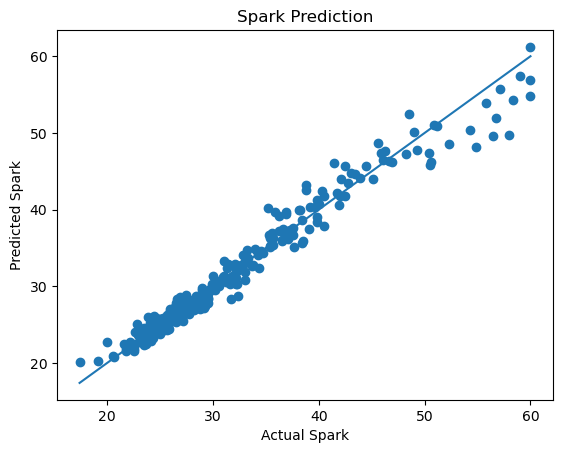

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ==========================================================
# LOAD DATA
# ==========================================================
df = pd.read_excel(r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\CNG_DATA_MODELING.xlsx")
# =====================================================
# VALID COMBUSTION FILTERS
# =====================================================
df = df[
    (df["MFB50_0"].between(6,25)) &
   (df["CIMEP1"].between(0,6))
]
df = df[
    (df["EM_THC_2"] <= 10000) &
   (df["EM_NOX_2"] <= 5000) &
   (df["EM_COH_2"] <= 20000)
]
print(len(df))
# ==========================================================
# CLEAN DATA
# ==========================================================
df = df.dropna(subset=[
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round",
    "TORQUE",
    "BSFC",
    "ADVOBJSS"
])
# ==========================================================
# SPARK MODEL (ADVOBJSS PREDICTION)
# ==========================================================

features_spark = [
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round"
]

df_spark = df.dropna(subset=features_spark + ["ADVOBJSS"]).reset_index(drop=True)

X_spark = df_spark[features_spark]
y_spark = df_spark["ADVOBJSS"]

# ----------------------------------------------------------
# TRAIN TEST SPLIT
# ----------------------------------------------------------
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_spark, y_spark, test_size=0.2, random_state=42
)

print("\nSpark Training Samples:", len(X_train_s))
print("Spark Testing Samples :", len(X_test_s))

# ----------------------------------------------------------
# MODEL
# ----------------------------------------------------------
gp_spark = build_gp()

print("\nTraining Spark Model...")
gp_spark.fit(X_train_s, y_train_s)
joblib.dump(gp_spark,"spark_model.pkl")


# ----------------------------------------------------------
# PREDICT
# ----------------------------------------------------------
pred_spark = gp_spark.predict(X_test_s)

# ----------------------------------------------------------
# METRICS
# ----------------------------------------------------------
print("\nSpark Model Performance")
print("-------------------------")
print("R2   :", r2_score(y_test_s, pred_spark))
print("MAE  :", mean_absolute_error(y_test_s, pred_spark))
print("RMSE :", np.sqrt(mean_squared_error(y_test_s, pred_spark)))




plt.figure()
plt.scatter(y_test_s, pred_spark)
plt.plot([y_test_s.min(), y_test_s.max()],
         [y_test_s.min(), y_test_s.max()])
plt.xlabel("Actual Spark")
plt.ylabel("Predicted Spark")
plt.title("Spark Prediction")
plt.show()








Training EM_NOX_2 model...
R2   : 0.9804746885306254
MAE  : 90.63273290182532
RMSE : 130.06920213614


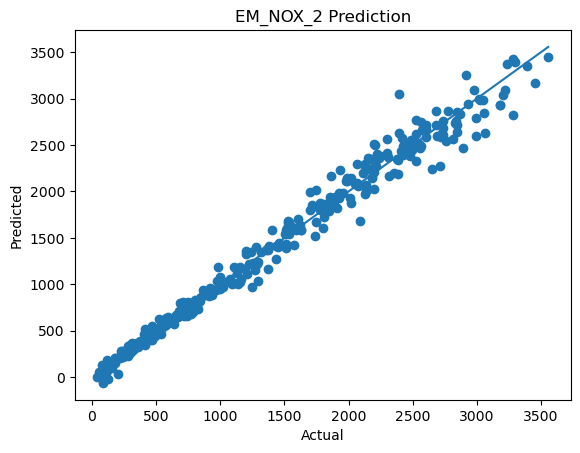

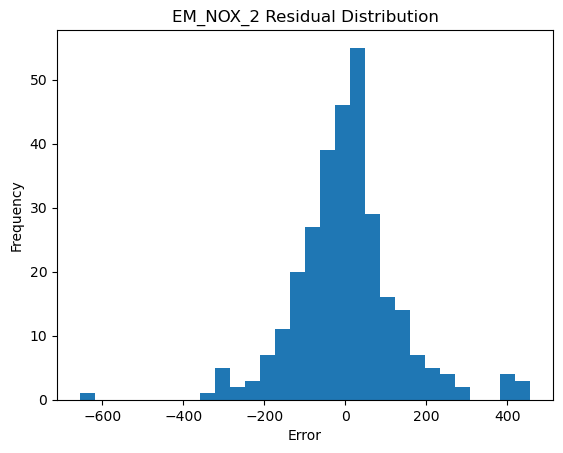

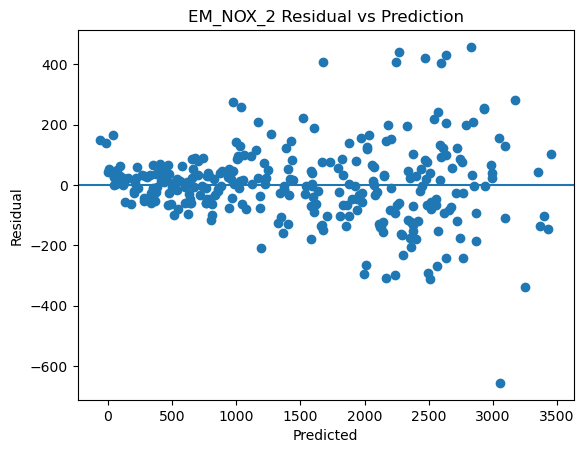


Training EM_THC_2 model...
R2   : 0.6264666559912782
MAE  : 419.44917447861826
RMSE : 1190.9902010718683


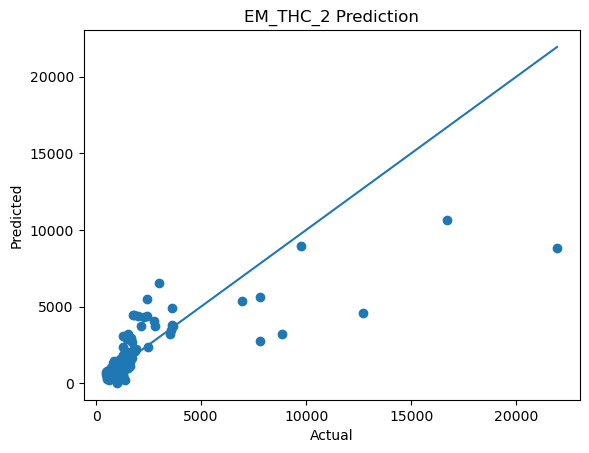

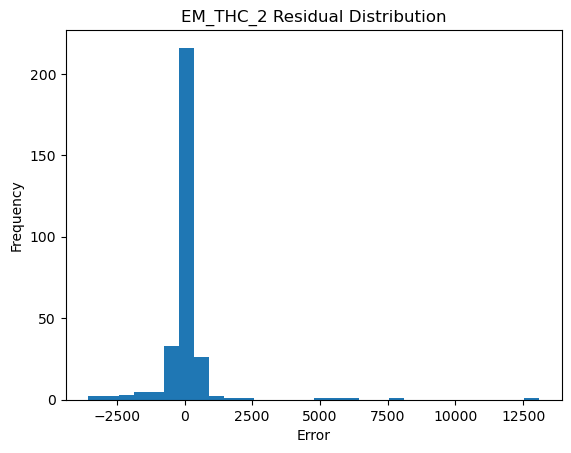

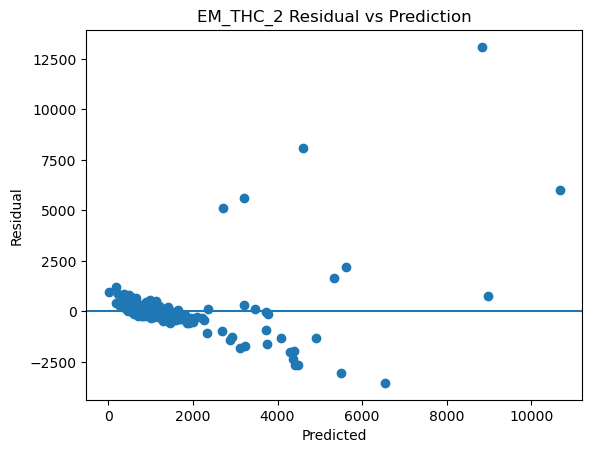


Training EM_COH_2 model...
R2   : 0.33580584260303403
MAE  : 533.5387730422847
RMSE : 1014.3830126315243


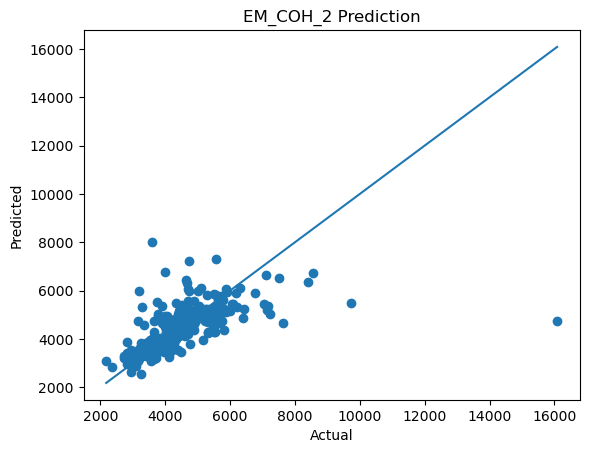

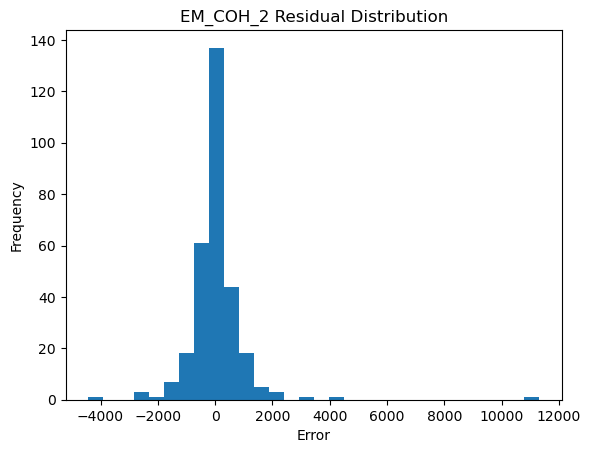

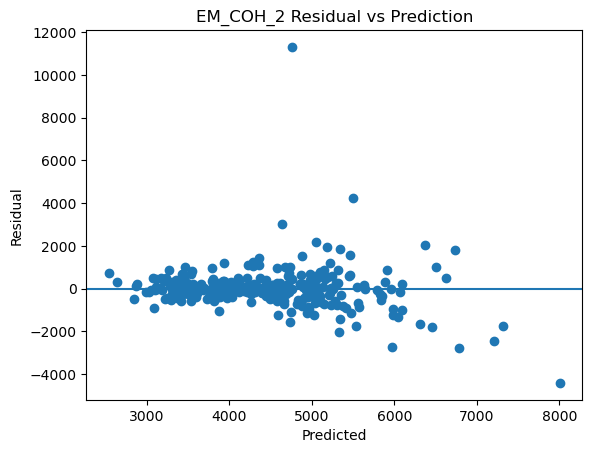

In [16]:
# ==========================================================
# EMISSIONS MODELS + RESIDUAL PLOTS
# ==========================================================

emission_targets = ["EM_NOX_2", "EM_THC_2", "EM_COH_2"]

gp_emissions = {}

df = pd.read_excel(r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\CNG_DATA_MODELING.xlsx")

for target in emission_targets:

    print(f"\nTraining {target} model...")

    df_em = df.dropna(subset=features + [target]).reset_index(drop=True)

    X_em = df_em[features]
    y_em = df_em[target].clip(lower=0)

    # split
    X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
        X_em, y_em, test_size=0.2, random_state=42
    )

    # train
    model = build_gp()
    model.fit(X_train_e, y_train_e)
    joblib.dump(model, f"{target}_model.pkl")


    # predict
    pred = model.predict(X_test_e)

    # metrics
    print("R2   :", r2_score(y_test_e, pred))
    print("MAE  :", mean_absolute_error(y_test_e, pred))
    print("RMSE :", np.sqrt(mean_squared_error(y_test_e, pred)))

    gp_emissions[target] = model

    # ======================================================
    # PLOTS
    # ======================================================

    # ---- Predicted vs Actual
    plt.figure()
    plt.scatter(y_test_e, pred)
    plt.plot([y_test_e.min(), y_test_e.max()],
             [y_test_e.min(), y_test_e.max()])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{target} Prediction")
    plt.show()

    # ---- Residuals
    residuals = y_test_e - pred

    # Histogram
    plt.figure()
    plt.hist(residuals, bins=30)
    plt.title(f"{target} Residual Distribution")
    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.show()

    # Residual vs prediction
    plt.figure()
    plt.scatter(pred, residuals)
    plt.axhline(0)
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"{target} Residual vs Prediction")
    plt.show()


In [17]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================
df = pd.read_excel(r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\CNG_DATA_MODELING.xlsx")

# ======================================================
# APPLY SAME FILTERS USED DURING TRAINING
# ======================================================
df = df[
    (df["MFB50_0"].between(6,25)) &
    (df["CIMEP1"].between(0,6))
]

df = df[
    (df["EM_THC_2"] <= 10000) &
    (df["EM_NOX_2"] <= 5000) &
    (df["EM_COH_2"] <= 20000)
]

df = df.dropna(subset=[
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round",
    "TORQUE",
    "BSFC",
    "ADVOBJSS"
])

print("Dataset size:", len(df))


# ======================================================
# FEATURES
# ======================================================
features = [
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round"
]


# ======================================================
# LOAD MODELS
# ======================================================
models = {
    "Torque": ("TORQUE", joblib.load("torque_model.pkl")),
    "BSFC": ("BSFC", joblib.load("bsfc_model.pkl")),
    "Spark": ("ADVOBJSS", joblib.load("spark_model.pkl")),
    "NOx": ("EM_NOX_2", joblib.load("EM_NOX_2_model.pkl")),
    "THC": ("EM_THC_2", joblib.load("EM_THC_2_model.pkl")),
    "COH": ("EM_COH_2", joblib.load("EM_COH_2_model.pkl"))
}

print("\nAll models loaded successfully")


# ======================================================
# GLOBAL PERFORMANCE
# ======================================================
print("\n================ GLOBAL PERFORMANCE ================")

for name,(target,model) in models.items():

    if name=="BSFC":
        pred = np.exp(model.predict(df[features]))
    else:
        pred = model.predict(df[features])

    r2   = r2_score(df[target], pred)
    rmse = np.sqrt(mean_squared_error(df[target], pred))

    print(f"{name:<6}  R2 = {r2:.4f}     RMSE = {rmse:.3f}")

    df[f"Pred_{name}"] = pred


# ======================================================
# RPM-WISE PERFORMANCE
# ======================================================
print("\n\n================ RPM WISE PERFORMANCE ================")

for name,(target,model) in models.items():

    print(f"\n{name} MODEL")
    print("--------------------------------------")
    print("RPM       R2        RMSE")

    for rpm, g in df.groupby("SPEED"):

        if len(g) > 2:
            r2   = r2_score(g[target], g[f"Pred_{name}"])
            rmse = np.sqrt(mean_squared_error(g[target], g[f"Pred_{name}"]))

            print(f"{rpm:<6}   {r2:.4f}     {rmse:.3f}")


Dataset size: 1377

All models loaded successfully

================ GLOBAL PERFORMANCE ================
Torque  R2 = 0.9994     RMSE = 0.537
BSFC    R2 = 0.0248     RMSE = 2437.057
Spark   R2 = 0.9620     RMSE = 1.654
NOx     R2 = 0.9761     RMSE = 134.264
THC     R2 = 0.2157     RMSE = 318.473
COH     R2 = 0.7005     RMSE = 566.244


================ RPM WISE PERFORMANCE ================

Torque MODEL
--------------------------------------
RPM       R2        RMSE
1500     0.9996     0.425
1750     0.9995     0.465
2000     0.9987     0.755
2250     0.9992     0.649
2500     0.9988     0.820
2750     0.9987     0.811
3000     0.9998     0.334
3250     0.9999     0.223
3500     0.9996     0.452
4000     0.9998     0.385
4500     0.9999     0.248

BSFC MODEL
--------------------------------------
RPM       R2        RMSE
1500     0.9098     29.120
1750     0.9805     10.715
2000     0.9339     24.166
2250     0.6908     120.344
2500     0.8897     55.461
2750     0.9267     40.142
3000

In [18]:
# ==========================================================
# DEFINE FULL GRID VALUES
# ==========================================================

rpm_vals = [
700,800,900,1000,1100,1250,1500,1750,2000,2250,
2500,2750,3000,3250,3500,4000,4500,5000,5500,6000,6500
]

load_vals = [
0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,
0.55,0.6,0.7,0.8,0.9,1,1.05]

# ✔ UPDATED VVT VALUES
vvt_int_vals = [0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,50]
vvt_exh_vals = [0,-2,-4,-6,-8,-10,-12,-14,-16,-18,-20,-22,-24,-26,-28,-30,-32,-34,-36,-38,-40,-42,-44,-46,-48,-50]

# ==========================================================
# BUILD FULL GRID
# ==========================================================
grid = []

for rpm in rpm_vals:
    for load in load_vals:
        for iv in vvt_int_vals:
            for ev in vvt_exh_vals:
                grid.append([rpm, load, iv, ev])

grid_df = pd.DataFrame(grid, columns=[
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round"
])

print("Total prediction points:", len(grid_df))   # should print 9720


# ==========================================================
# PREDICT USING TRAINED MODELS
# ==========================================================

X_pred = grid_df[[
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round"
]]

# Torque
grid_df["Pred_Torque"] = gp_torque.predict(X_pred)

# BSFC
grid_df["Pred_BSFC"] = np.exp(gp_bsfc.predict(X_pred))

# Spark (if model exists)
if "gp_spark" in globals():
    grid_df["Pred_Spark"] = gp_spark.predict(X_pred)


# ==========================================================
# SAVE FILE
# ==========================================================
output_path = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_without_Emissions.xlsx"
grid_df.to_excel(output_path, index=False)

print("\nPrediction completed successfully")
print("Saved at:", output_path)


Total prediction points: 227136

Prediction completed successfully
Saved at: D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_without_Emissions.xlsx


In [19]:
# ==========================================================
# PREDICT USING TRAINED MODELS
# ==========================================================

# ---- Input features for prediction
X_pred = grid_df[[
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round"
]]

# ----------------------------------------------------------
# TORQUE PREDICTION
# ----------------------------------------------------------
grid_df["Pred_Torque"] = gp_torque.predict(X_pred)

# ----------------------------------------------------------
# BSFC PREDICTION (log trained → exp back)
# ----------------------------------------------------------
grid_df["Pred_BSFC"] = np.exp(gp_bsfc.predict(X_pred))

# ----------------------------------------------------------
# SPARK PREDICTION (if model exists)
# ----------------------------------------------------------
if "gp_spark" in globals():
    grid_df["Pred_Spark"] = gp_spark.predict(X_pred)

# ----------------------------------------------------------
# EMISSIONS PREDICTION (NOx / THC / CO)
# ----------------------------------------------------------
if "gp_emissions" in globals():

    for target, model in gp_emissions.items():
        grid_df[f"Pred_{target}"] = model.predict(X_pred)


# ==========================================================
# SAVE FILE
# ==========================================================
output_path = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx"
grid_df.to_excel(output_path, index=False)

print("\nPrediction completed successfully")
print("Saved at:", output_path)



Prediction completed successfully
Saved at: D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy.interpolate import griddata


def plot_all_maps(excel_path, speed, load, best_ivvt, best_evvt):

    df = pd.read_excel(excel_path)

    df_sel = df[(df["SPEED"] == speed) & (df["ETASP_Cal"] == load)]

    print("Points found:", len(df_sel))

    VVT_I = df_sel["VVTPHOBJ_round"].values
    VVT_E = df_sel["VVTPHOBJ_EXH_round"].values

    # outputs available
    outputs = {
        "BSFC" : "Pred_BSFC",
        "Torque" : "Pred_Torque",
        "Spark" : "Pred_Spark",
        "NOx" : "Pred_EM_NOX_2",
        "THC" : "Pred_EM_THC_2",
        "COH" : "Pred_EM_COH_2"
    }

    # keep only columns that exist
    outputs = {k:v for k,v in outputs.items() if v in df_sel.columns}

    nplots = len(outputs)

    fig, axes = plt.subplots(nplots, 1, figsize=(9,5*nplots))
    if nplots == 1:
        axes = [axes]

    # interpolation grid
    xi = np.linspace(VVT_I.min(), VVT_I.max(), 150)
    yi = np.linspace(VVT_E.min(), VVT_E.max(), 150)
    xi, yi = np.meshgrid(xi, yi)

    # grid label points
    A = np.linspace(VVT_I.min(), VVT_I.max(), 6)
    B = np.linspace(VVT_E.max(), VVT_E.min(), 6)
    label_pts = np.array([(x,y) for x in A for y in B])


    # colormaps
    cmap_dict = {
        "BSFC": LinearSegmentedColormap.from_list("",["green","yellow","orange","red"]),
        "Torque": LinearSegmentedColormap.from_list("",["gray","green","blue"]),
        "Spark": "plasma",
        "NOx": "magma",
        "THC": "viridis",
        "COH": "coolwarm"
    }


    # ============================================
    # LOOP THROUGH OUTPUTS
    # ============================================
    for ax,(name,col) in zip(axes, outputs.items()):

        Z = df_sel[col].values

        zi = griddata((VVT_I,VVT_E), Z, (xi,yi), method="cubic")

        ax.contour(xi,yi,zi, levels=20, colors="black", linewidths=0.5)
        cf = ax.contourf(xi,yi,zi, levels=20, cmap=cmap_dict.get(name,"viridis"))

        # crosshair best point
        ax.axvline(best_ivvt, color="black", linestyle="--", linewidth=1.5)
        ax.axhline(best_evvt, color="black", linestyle="--", linewidth=1.5)

        # value labels
        vals = griddata((VVT_I,VVT_E), Z, label_pts, method="cubic")

        for (x,y),v in zip(label_pts,vals):
            if not np.isnan(v):
                ax.text(x,y,f"{v:.0f}", ha="center", va="center", fontsize=9)

        ax.set_xlim(-10,60)
        ax.set_ylim(-60,10)
        ax.set_xlabel("IVVT")
        ax.set_ylabel("EVVT")
        ax.set_title(f"{name} Map | Speed={speed} Load={load}")

        fig.colorbar(cf, ax=ax)

    # border
    rect = Rectangle((0,0),1,1, transform=fig.transFigure,
                     facecolor='none', edgecolor='black', linewidth=2)
    fig.patches.append(rect)

    plt.tight_layout()
    plt.show()


Points found: 676


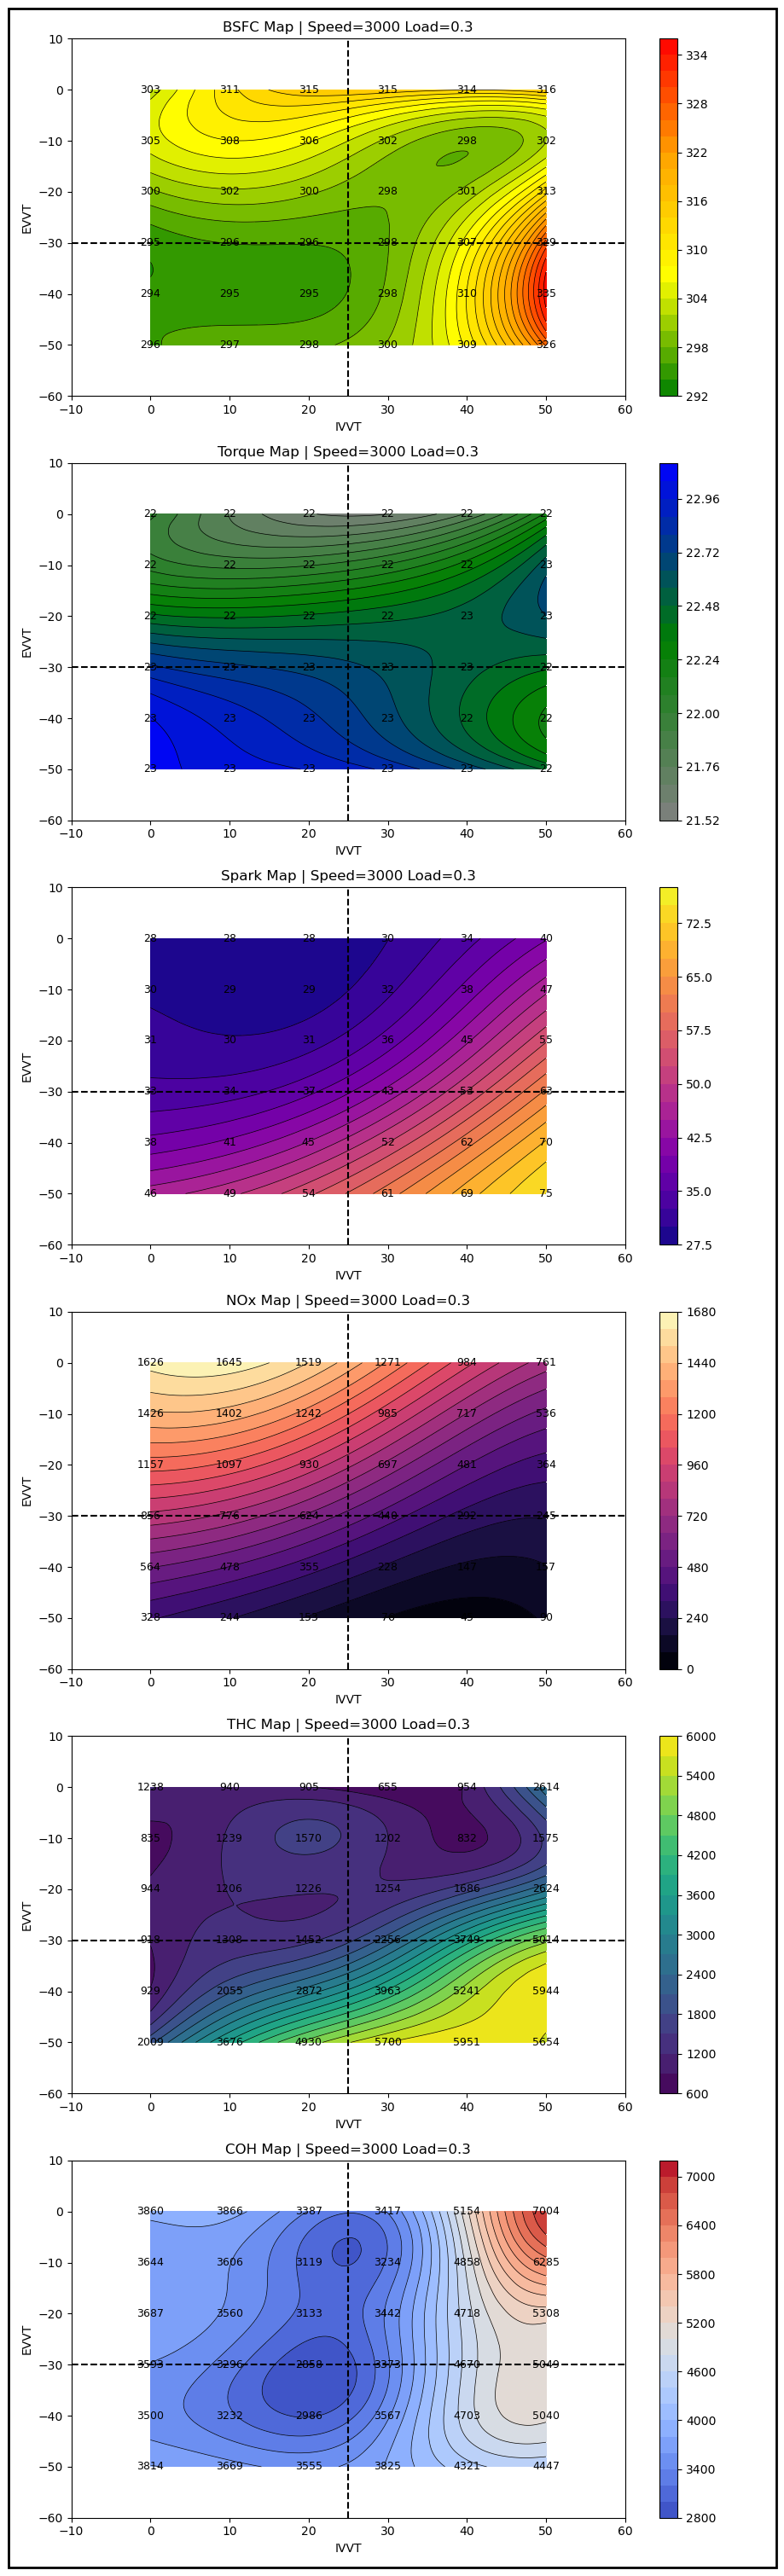

In [21]:
plot_all_maps(
    excel_path = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx",
    speed = 3000,
    load = 0.3,
    best_ivvt = 25,
    best_evvt = -30
)


In [22]:
import pandas as pd
import numpy as np

# ==========================================
# LOAD PREDICTION FILE
# ==========================================
df = pd.read_excel(r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx")

# ==========================================
# SELECT OPERATING POINT
# ==========================================
speed = 700
load  = 0.15

df_sel = df[(df["SPEED"] == speed) & (df["ETASP_Cal"] == load)].copy()

# ==========================================
# APPLY VVT CONSTRAINTS
# IVVT → 0 to 45
# EVVT → 0 to -45
# ==========================================
df_sel = df_sel[
    (df_sel["VVTPHOBJ_round"].between(0,45)) &
    (df_sel["VVTPHOBJ_EXH_round"].between(-45,0))
]

print("Rows after VVT constraint:", len(df_sel))


# ==========================================
# CREATE EMISSION SCORE
# ==========================================
df_sel["EmissionScore"] = (
    df_sel["Pred_EM_NOX_2"] +
    df_sel["Pred_EM_THC_2"] +
    df_sel["Pred_EM_COH_2"]
)


# ==========================================
# STABLE OPTIMUM LOGIC
# ==========================================
tol = 0.01   # 1% tolerance



# ---------- PART LOAD (<0.65) ----------
if load < 0.65:

    print("\nOperating Region: PART LOAD")

    # Step 1 → minimum BSFC
    best_bsfc = df_sel["Pred_BSFC"].min()

    # Step 2 → candidates within tolerance
    candidates = df_sel[df_sel["Pred_BSFC"] <= best_bsfc * (1 + tol)]

    print("Candidates within 1% BSFC:", len(candidates))

    # Step 3 → stable selection
    best = candidates.sort_values(
        by=["Pred_Torque", "EmissionScore"],
        ascending=[False, True]
    ).iloc[0]
        # ==========================================
    # CALIBRATION OVERRIDE RULES (POST SELECTION)
    # ==========================================
    
    final_ivvt = best["VVTPHOBJ_round"]
    final_evvt = best["VVTPHOBJ_EXH_round"]
    
    # ---------- RULE 1 : IDLE ZONE ----------
    if 700 <= speed <= 900 and 0.1 <= load <= 1.05:
        final_ivvt = 0
        final_evvt = 0
        rule = "Idle override"
    
    # ---------- RULE 2 : LOW LOAD ZONE ----------
    elif 1000 <= speed <= 6500 and 0.1 <= load <= 0.2:
    
        # Special exception
        if 2000 <= speed <= 3500 and load == 0.2:
            final_ivvt = 0
            rule = "Low load exception zone"
    
        else:
            final_ivvt = 0
            final_evvt = 0
            rule = "Low load override"
    
    # ---------- NORMAL REGION ----------
    else:
        rule = "Optimizer result"


# ---------- FULL LOAD (>=0.65) ----------
else:
    print("\nOperating Region: FULL LOAD")

    # Step 1 → maximum torque
    best_torque = df_sel["Pred_Torque"].max()

    # Step 2 → candidates within tolerance
    candidates = df_sel[df_sel["Pred_Torque"] >= best_torque * (1 - tol)]

    print("Candidates within 1% Torque:", len(candidates))

    # Step 3 → stable selection
    best = candidates.sort_values(
        by=["Pred_BSFC", "EmissionScore"],
        ascending=[True, True]
    ).iloc[0]
    # ==========================================
    # CALIBRATION OVERRIDE RULES (POST SELECTION)
    # ==========================================
    
    final_ivvt = best["VVTPHOBJ_round"]
    final_evvt = best["VVTPHOBJ_EXH_round"]
    
    # ---------- RULE 1 : IDLE ZONE ----------
    if 700 <= speed <= 900 and 0.1 <= load <= 1.05:
        final_ivvt = 0
        final_evvt = 0
        rule = "Idle override"
    
    # ---------- RULE 2 : LOW LOAD ZONE ----------
    elif 1000 <= speed <= 6500 and 0.1 <= load <= 0.2:
    
        # Special exception
        if 2000 <= speed <= 3500 and load == 0.2:
            final_ivvt = 0
            rule = "Low load exception zone"
    
        else:
            final_ivvt = 0
            final_evvt = 0
            rule = "Low load override"
    
    # ---------- NORMAL REGION ----------
    else:
        rule = "Optimizer result"


# ==========================================
# PRINT FINAL RESULT
# ==========================================
print("\n======== BEST VVT SELECTION ========")
print(f"Speed        : {speed}")
print(f"Load         : {load}")
print("--------------------------------------")
print(f"Best IVVT    : {final_ivvt}")
print(f"Best EVVT    : {final_evvt}")
print(f"SelectionRule: {rule}")
print("--------------------------------------")
print(f"Torque       : {best['Pred_Torque']:.2f}")
print(f"BSFC         : {best['Pred_BSFC']:.2f}")
print(f"NOx          : {best['Pred_EM_NOX_2']:.2f}")
print(f"THC          : {best['Pred_EM_THC_2']:.2f}")
print(f"COH          : {best['Pred_EM_COH_2']:.2f}")
print(f"EmissionScore: {best['EmissionScore']:.2f}")
print("======================================")


Rows after VVT constraint: 529

Operating Region: PART LOAD
Candidates within 1% BSFC: 9

======== BEST VVT SELECTION ========
Speed        : 700
Load         : 0.15
--------------------------------------
Best IVVT    : 0
Best EVVT    : 0
SelectionRule: Idle override
--------------------------------------
Torque       : 4.20
BSFC         : 502.18
NOx          : -131.09
THC          : 6999.49
COH          : 4649.93
EmissionScore: 11518.33


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy.interpolate import griddata


def plot_all_maps(excel_path, speed, load):

    df = pd.read_excel(excel_path)

    df_sel = df[(df["SPEED"] == speed) & (df["ETASP_Cal"] == load)].copy()

    print("Points found:", len(df_sel))


    # ============================================
    # EMISSION SCORE
    # ============================================
    df_sel["EmissionScore"] = (
        df_sel["Pred_EM_NOX_2"] +
        df_sel["Pred_EM_THC_2"] +
        df_sel["Pred_EM_COH_2"]
    )


    # ============================================
    # STABLE BEST VVT SELECTION (UPDATED LOGIC)
    # ============================================
    tol = 0.01
    
    # ---- APPLY VVT CONSTRAINTS ONLY FOR SELECTION ----
    df_constrained = df_sel[
        (df_sel["VVTPHOBJ_round"].between(0,45)) &
        (df_sel["VVTPHOBJ_EXH_round"].between(-45,0))
    ]
    
    print("Points inside constraint:", len(df_constrained))
    print("Points after VVT constraint:", len(df_sel))
    
    
    # ---------- PART LOAD (<0.65) ----------
    if load < 0.65:
    
        best_bsfc = df_constrained["Pred_BSFC"].min()
        candidates = df_constrained[df_constrained["Pred_BSFC"] <= best_bsfc*(1+tol)]
    
        best = candidates.sort_values(
            by=["Pred_Torque","EmissionScore"],
            ascending=[False,True]
        ).iloc[0]
    
        print("Mode: PART LOAD")
    
    
    # ---------- FULL LOAD (>=0.65) ----------
    else:
    
        best_torque = df_constrained["Pred_Torque"].max()
        candidates = df_constrained[df_constrained["Pred_Torque"] >= best_torque*(1-tol)]
    
        best = candidates.sort_values(
            by=["Pred_BSFC","EmissionScore"],
            ascending=[True,True]
        ).iloc[0]
    
        print("Mode: FULL LOAD")


    # ============================================
    # EXTRACT BEST FROM OPTIMIZER
    # ============================================
    best_ivvt = best["VVTPHOBJ_round"]
    best_evvt = best["VVTPHOBJ_EXH_round"]


    # ============================================
    # CALIBRATION OVERRIDE RULES
    # ============================================
    rule = "Optimizer result"

    # ---- IDLE ZONE ----
    if 700 <= speed <= 900 and 0.1 <= load <= 1.05:
        best_ivvt = 0
        best_evvt = 0
        rule = "Idle override"

    # ---- LOW LOAD ZONE ----
    elif 1000 <= speed <= 6500 and 0.1 <= load <= 0.2:

        # Exception zone
        if 2000 <= speed <= 3500 and load == 0.2:
            best_ivvt = 0
            rule = "Low load exception"

        else:
            best_ivvt = 0
            best_evvt = 0
            rule = "Low load override"

    print("\nBest IVVT:", best_ivvt)
    print("Best EVVT:", best_evvt)
    print("Rule:", rule)


    # ============================================
    # INPUT GRID
    # ============================================
    VVT_I = df_sel["VVTPHOBJ_round"].values
    VVT_E = df_sel["VVTPHOBJ_EXH_round"].values


    # ============================================
    # OUTPUT VARIABLES
    # ============================================
    outputs = {
        "BSFC" : "Pred_BSFC",
        "Torque" : "Pred_Torque",
        "Spark" : "Pred_Spark",
        "NOx" : "Pred_EM_NOX_2",
        "THC" : "Pred_EM_THC_2",
        "COH" : "Pred_EM_COH_2"
    }

    outputs = {k:v for k,v in outputs.items() if v in df_sel.columns}


    # ============================================
    # INTERPOLATION GRID
    # ============================================
    xi = np.linspace(VVT_I.min(), VVT_I.max(), 150)
    yi = np.linspace(VVT_E.min(), VVT_E.max(), 150)
    xi, yi = np.meshgrid(xi, yi)


    # label grid
    A = np.linspace(VVT_I.min(), VVT_I.max(), 6)
    B = np.linspace(VVT_E.max(), VVT_E.min(), 6)
    label_pts = np.array([(x,y) for x in A for y in B])


    # ============================================
    # COLORMAPS
    # ============================================
    cmap_dict = {
        "BSFC": LinearSegmentedColormap.from_list("",["green","yellow","orange","red"]),
        "Torque": LinearSegmentedColormap.from_list("",["gray","green","blue"]),
        "Spark": "plasma",
        "NOx": "magma",
        "THC": "viridis",
        "COH": "coolwarm"
    }


    # ============================================
    # PLOT
    # ============================================
    fig, axes = plt.subplots(len(outputs), 1, figsize=(9,5*len(outputs)))

    if len(outputs)==1:
        axes=[axes]


    for ax,(name,col) in zip(axes, outputs.items()):

        Z = df_sel[col].values

        zi = griddata((VVT_I,VVT_E), Z, (xi,yi), method="cubic")

        ax.contour(xi,yi,zi, levels=20, colors="black", linewidths=0.5)
        cf = ax.contourf(xi,yi,zi, levels=20, cmap=cmap_dict.get(name,"viridis"))

        ax.scatter(best_ivvt, best_evvt,
                   s=250, color="red", edgecolor="black", zorder=5)

        ax.axvline(best_ivvt, color="black", linestyle="--", linewidth=1.5)
        ax.axhline(best_evvt, color="black", linestyle="--", linewidth=1.5)

        vals = griddata((VVT_I,VVT_E), Z, label_pts, method="cubic")

        for (x,y),v in zip(label_pts,vals):
            if not np.isnan(v):
                ax.text(x,y,f"{v:.0f}", ha="center", va="center", fontsize=9)

        ax.set_xlim(-10,60)
        ax.set_ylim(-60,10)
        ax.set_xlabel("IVVT")
        ax.set_ylabel("EVVT")
        ax.set_title(f"{name} Map | Speed={speed} Load={load}")

        fig.colorbar(cf, ax=ax)


    rect = Rectangle((0,0),1,1, transform=fig.transFigure,
                     facecolor='none', edgecolor='black', linewidth=2)
    fig.patches.append(rect)

    plt.tight_layout()
    plt.show()

Points found: 676
Points inside constraint: 529
Points after VVT constraint: 676
Mode: PART LOAD

Best IVVT: 0.0
Best EVVT: -44.0
Rule: Optimizer result


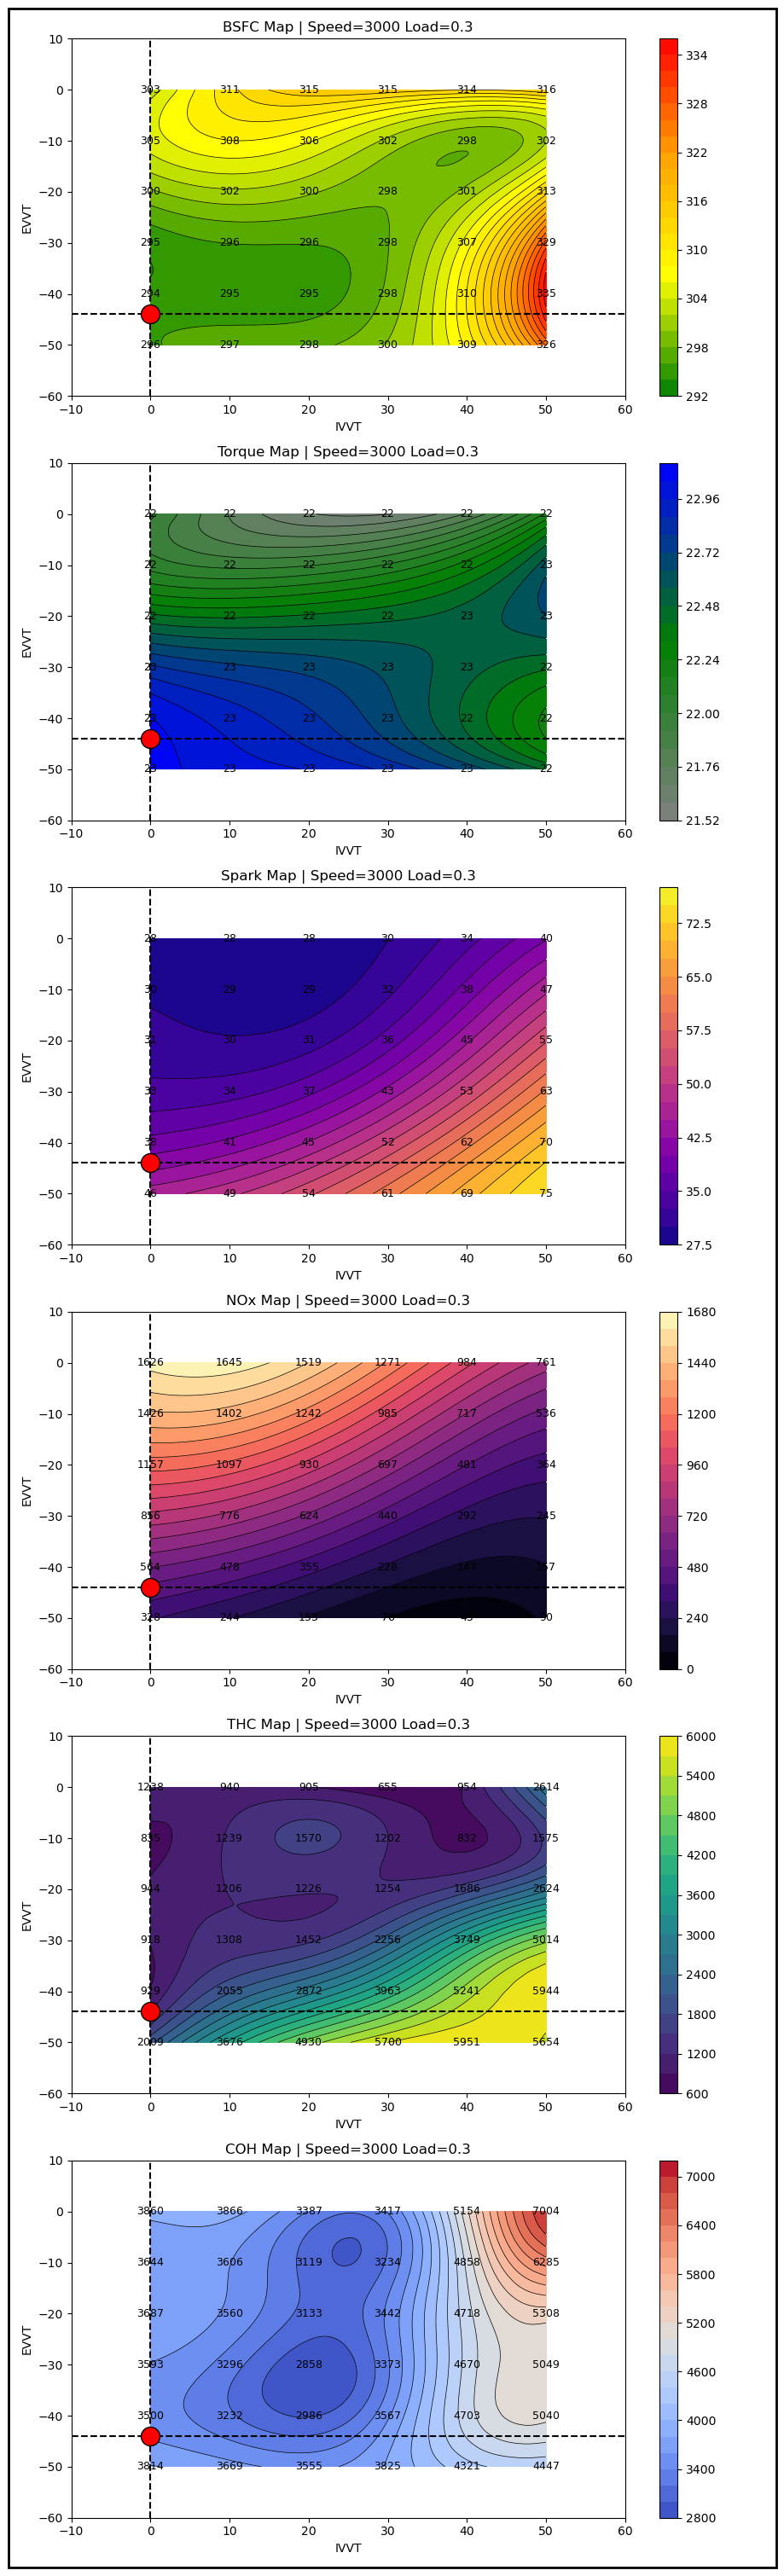

In [24]:
plot_all_maps(
    r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx",
    speed=3000,
    load=0.3
)


In [25]:
import pandas as pd
import numpy as np

# ===============================================
# LOAD FILE
# ===============================================
file_path = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx"
df = pd.read_excel(file_path)

# ===============================================
# OUTPUT FILE
# ===============================================
output_path = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Best_VVT_Map.xlsx"

writer = pd.ExcelWriter(output_path, engine="openpyxl")

tol = 0.01

# ===============================================
# LOOP THROUGH SPEEDS
# ===============================================
for speed in sorted(df["SPEED"].unique()):

    df_speed = df[df["SPEED"] == speed]

    results = []

    # -------------------------------------------
    # LOOP THROUGH LOADS
    # -------------------------------------------
    for load in sorted(df_speed["ETASP_Cal"].unique()):

        group = df_speed[df_speed["ETASP_Cal"] == load].copy()

        # emission score
        group["EmissionScore"] = (
            group["Pred_EM_NOX_2"] +
            group["Pred_EM_THC_2"] +
            group["Pred_EM_COH_2"]
        )

        # =======================================
        # SELECTION LOGIC (SAME AS YOUR FUNCTION)
        # =======================================
        # =======================================
        # UPDATED SELECTION LOGIC
        # =======================================
        
        # ---- VVT CONSTRAINT FOR OPTIMIZER ----
        group_cons = group[
            (group["VVTPHOBJ_round"].between(0,45)) &
            (group["VVTPHOBJ_EXH_round"].between(-45,0))
        ]
        
        # ---------- PART LOAD (<0.65) ----------
        if load < 0.65:
        
            best_bsfc = group_cons["Pred_BSFC"].min()
            candidates = group_cons[group_cons["Pred_BSFC"] <= best_bsfc*(1+tol)]
        
            best = candidates.sort_values(
                by=["Pred_Torque","EmissionScore"],
                ascending=[False,True]
            ).iloc[0]
        
        # ---------- FULL LOAD (>=0.65) ----------
        else:
        
            best_torque = group_cons["Pred_Torque"].max()
            candidates = group_cons[group_cons["Pred_Torque"] >= best_torque*(1-tol)]
        
            best = candidates.sort_values(
                by=["Pred_BSFC","EmissionScore"],
                ascending=[True,True]
            ).iloc[0]
        
        
        # =======================================
        # CALIBRATION OVERRIDE RULES
        # =======================================
        
        best_ivvt = best["VVTPHOBJ_round"]
        best_evvt = best["VVTPHOBJ_EXH_round"]
        
        # ---- IDLE ZONE ----
        if 700 <= speed <= 900 and 0.1 <= load <= 1.05:
            best_ivvt = 0
            best_evvt = 0
        
        # ---- LOW LOAD ZONE ----
        elif 1000 <= speed <= 6500 and 0.1 <= load <= 0.2:
        
            # exception region
            if 2000 <= speed <= 3500 and load == 0.2:
                best_ivvt = 0
            else:
                best_ivvt = 0
                best_evvt = 0
        # store result
        results.append([
            load,
            best_ivvt,
            best_evvt,
            best["Pred_Torque"],
            best["Pred_BSFC"],
            best["Pred_EM_NOX_2"],
            best["Pred_EM_THC_2"],
            best["Pred_EM_COH_2"]
        ])


    # -------------------------------------------
    # CREATE DATAFRAME FOR SPEED SHEET
    # -------------------------------------------
    res_df = pd.DataFrame(results, columns=[
        "Load",
        "Best_IVVT",
        "Best_EVVT",
        "Torque",
        "BSFC",
        "NOx",
        "THC",
        "COH"
    ])

    # write sheet
    res_df.to_excel(writer, sheet_name=f"Speed_{int(speed)}", index=False)


# ===============================================
# SAVE FILE
# ===============================================
writer.close()

print("\n✅ Best VVT Map Generated Successfully")
print("Saved at:", output_path)



✅ Best VVT Map Generated Successfully
Saved at: D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Best_VVT_Map.xlsx



Plotting Speed=700 Load=0.1
Points found: 676
Points inside constraint: 529
Points after VVT constraint: 676
Mode: PART LOAD

Best IVVT: 0
Best EVVT: 0
Rule: Idle override


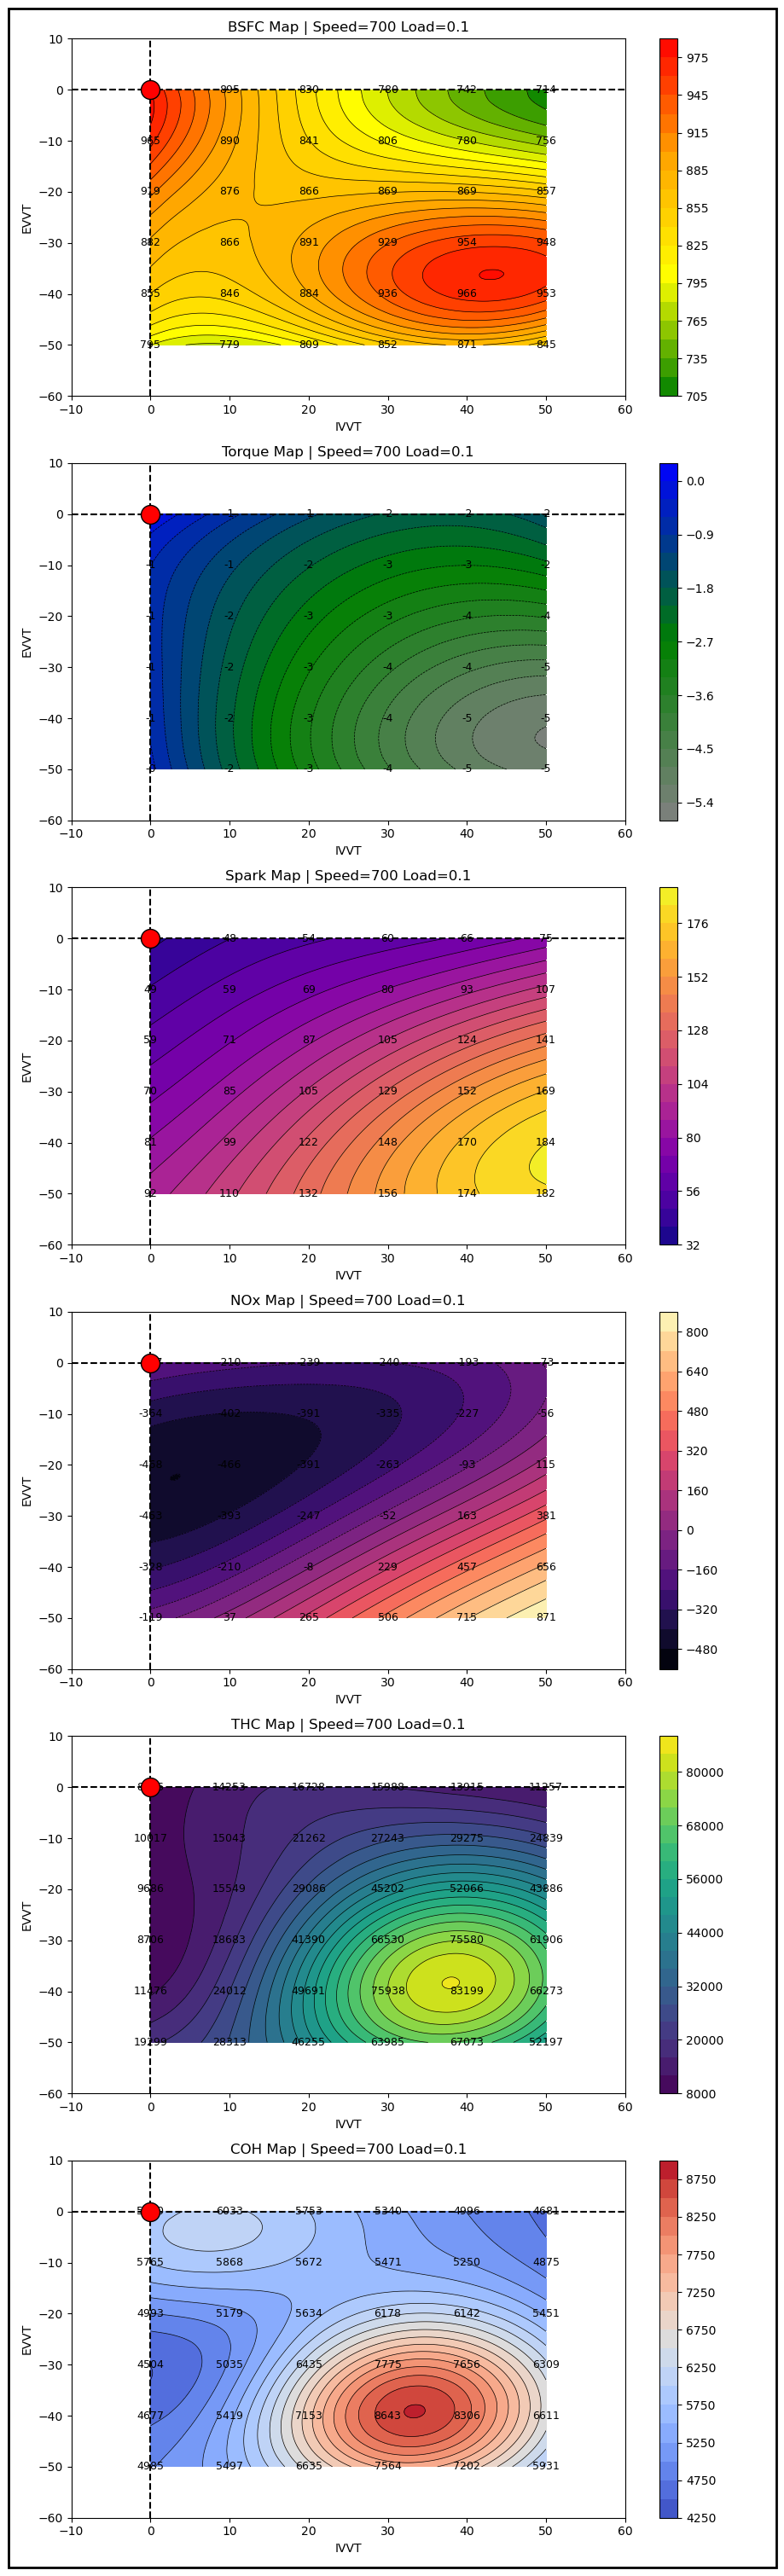


Plotting Speed=700 Load=0.15
Points found: 676
Points inside constraint: 529
Points after VVT constraint: 676
Mode: PART LOAD

Best IVVT: 0
Best EVVT: 0
Rule: Idle override


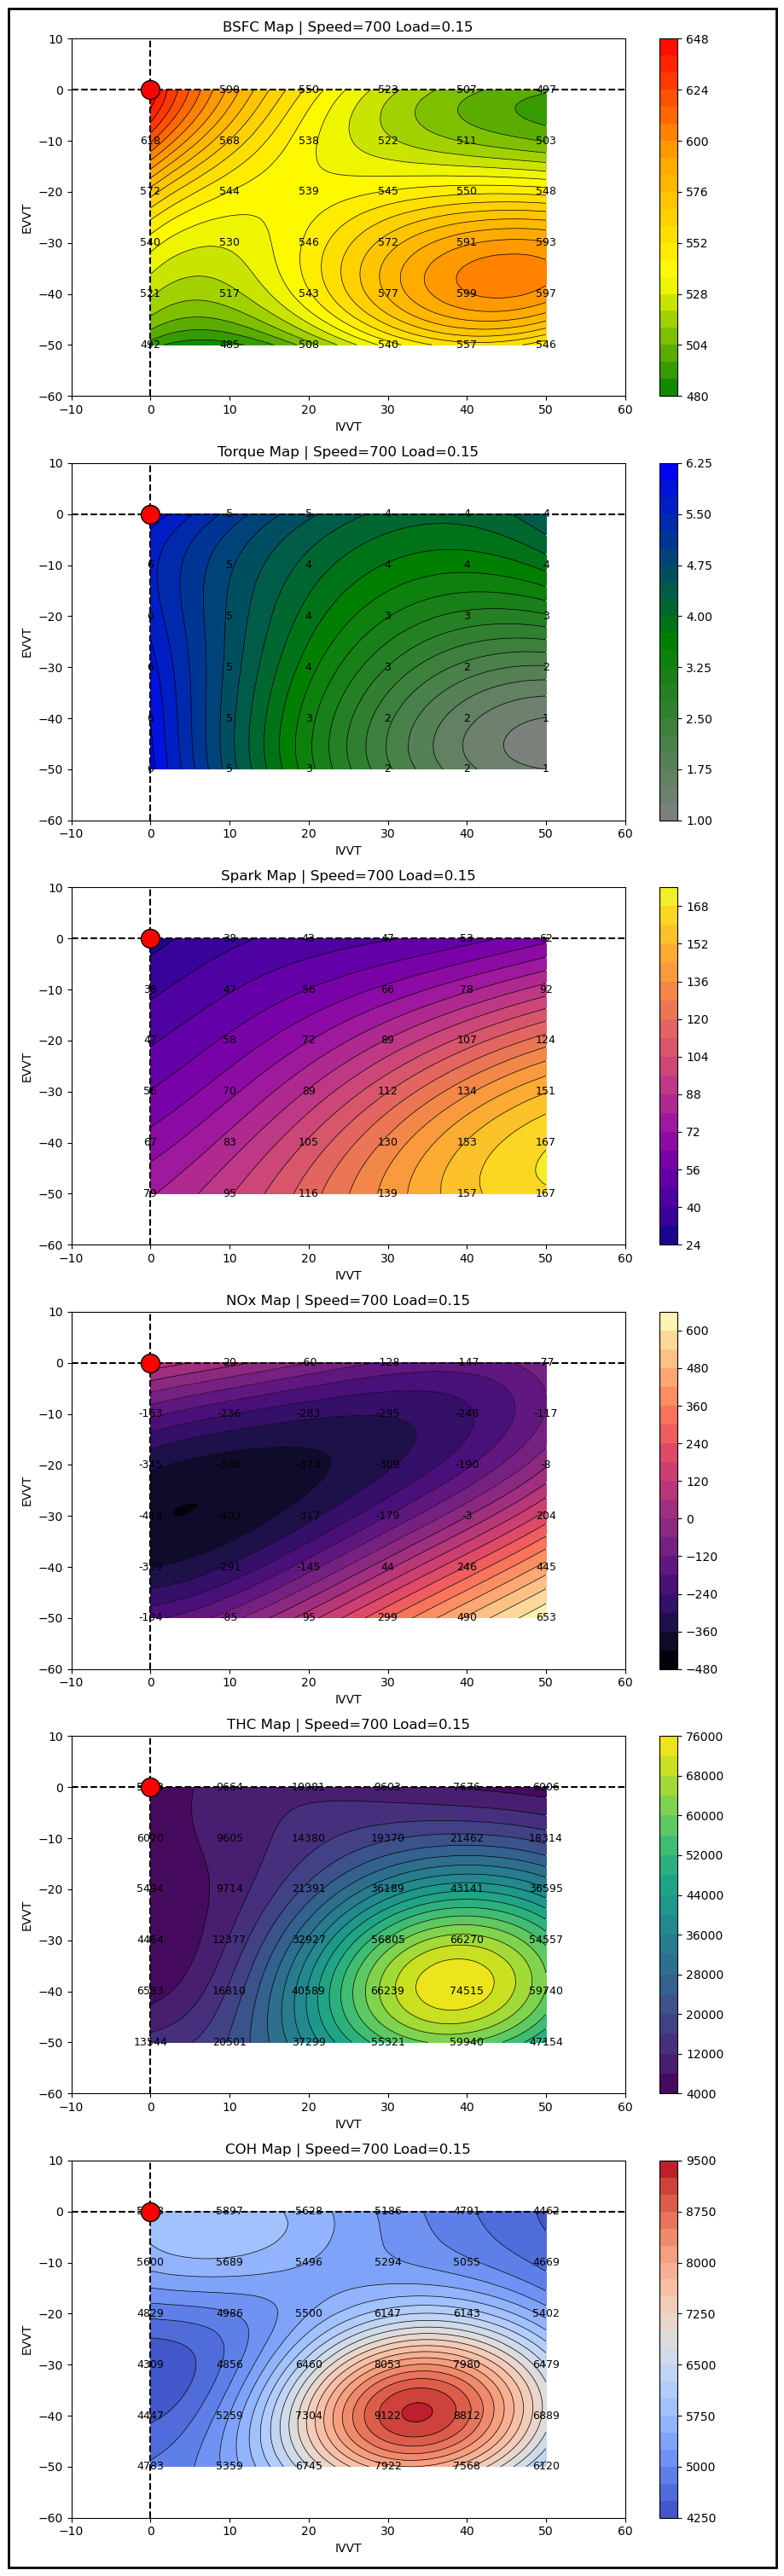


Plotting Speed=700 Load=0.2


KeyboardInterrupt: 

In [26]:
### Generation for all plots for EACH RPM wise it takes time here only it is printing ###
df = pd.read_excel(r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx")

for speed in sorted(df["SPEED"].unique()):
    for load in sorted(df[df["SPEED"]==speed]["ETASP_Cal"].unique()):

        print(f"\nPlotting Speed={speed} Load={load}")

        plot_all_maps(
            r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx",
            speed,
            load
        )
                                                                                                                                        

Saved maps to: D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Final_VVT_Maps_2deg.xlsx


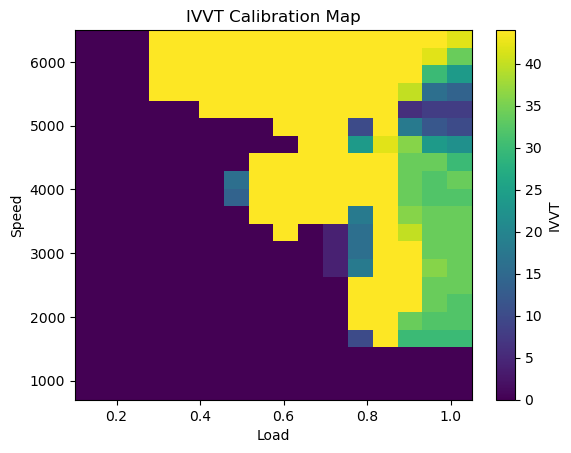

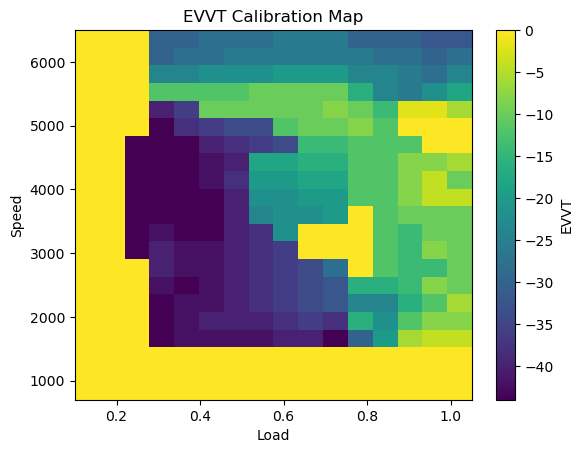

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# LOAD FILE
# ============================================
path = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx"
df = pd.read_excel(path)

tol = 0.01
rows = []

# ============================================
# FIND BEST VVT FOR ALL POINTS
# ============================================
for (speed, load), group in df.groupby(["SPEED","ETASP_Cal"]):

    group = group.copy()

    group["EmissionScore"] = (
        group["Pred_EM_NOX_2"] +
        group["Pred_EM_THC_2"] +
        group["Pred_EM_COH_2"]
    )

    # ============================================
    # APPLY VVT CONSTRAINT FOR SELECTION ONLY
    # ============================================
    group_cons = group[
        (group["VVTPHOBJ_round"].between(0,45)) &
        (group["VVTPHOBJ_EXH_round"].between(-45,0))
    ].copy()


    # ---------- PART LOAD (<0.65) ----------
    if load < 0.65:

        best_bsfc = group_cons["Pred_BSFC"].min()
        cand = group_cons[group_cons["Pred_BSFC"] <= best_bsfc*(1+tol)]

        best = cand.sort_values(
            by=["Pred_Torque","EmissionScore"],
            ascending=[False,True]
        ).iloc[0]


    # ---------- FULL LOAD (>=0.65) ----------
    else:

        best_torque = group_cons["Pred_Torque"].max()
        cand = group_cons[group_cons["Pred_Torque"] >= best_torque*(1-tol)]

        best = cand.sort_values(
            by=["Pred_BSFC","EmissionScore"],
            ascending=[True,True]
        ).iloc[0]


    # ============================================
    # CALIBRATION OVERRIDE RULES
    # ============================================
    best_ivvt = best["VVTPHOBJ_round"]
    best_evvt = best["VVTPHOBJ_EXH_round"]

    # ---- IDLE ZONE ----
    if 700 <= speed <= 900 and 0.1 <= load <= 1.05:
        best_ivvt = 0
        best_evvt = 0

    # ---- LOW LOAD ZONE ----
    elif 1000 <= speed <= 6500 and 0.1 <= load <= 0.2:

        # exception region
        if 2000 <= speed <= 3500 and load == 0.2:
            best_ivvt = 0
        else:
            best_ivvt = 0
            best_evvt = 0


    rows.append([
        speed,
        load,
        best_ivvt,
        best_evvt
    ])


best_df = pd.DataFrame(rows, columns=[
    "Speed","Load","IVVT","EVVT"
])


# ============================================
# CREATE MAP TABLES
# ============================================
ivvt_map = best_df.pivot(index="Speed", columns="Load", values="IVVT")
evvt_map = best_df.pivot(index="Speed", columns="Load", values="EVVT")


# ============================================
# SAVE EXCEL MAPS
# ============================================
out = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Final_VVT_Maps_2deg.xlsx"

with pd.ExcelWriter(out) as writer:
    ivvt_map.to_excel(writer, sheet_name="IVVT_Map")
    evvt_map.to_excel(writer, sheet_name="EVVT_Map")

print("Saved maps to:", out)


# ============================================
# PLOT IVVT MAP
# ============================================
plt.figure()
plt.imshow(ivvt_map, aspect="auto",
           extent=[ivvt_map.columns.min(),
                   ivvt_map.columns.max(),
                   ivvt_map.index.min(),
                   ivvt_map.index.max()],
           origin="lower")

plt.colorbar(label="IVVT")
plt.xlabel("Load")
plt.ylabel("Speed")
plt.title("IVVT Calibration Map")
plt.show()


# ============================================
# PLOT EVVT MAP
# ============================================
plt.figure()
plt.imshow(evvt_map, aspect="auto",
           extent=[evvt_map.columns.min(),
                   evvt_map.columns.max(),
                   evvt_map.index.min(),
                   evvt_map.index.max()],
           origin="lower")

plt.colorbar(label="EVVT")
plt.xlabel("Load")
plt.ylabel("Speed")
plt.title("EVVT Calibration Map")
plt.show()

In [29]:
import pandas as pd
import numpy as np
from scipy.ndimage import gaussian_filter

# =========================================================
# LOAD MAPS
# =========================================================
file_path = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Final_VVT_Maps_2deg.xlsx"

ivvt = pd.read_excel(file_path, sheet_name="IVVT_Map", index_col=0)
evvt = pd.read_excel(file_path, sheet_name="EVVT_Map", index_col=0)

ivvt = ivvt.astype(float)
evvt = evvt.astype(float)


# =========================================================
# MASK LOCKED ZONES
# =========================================================
def create_mask(df):

    mask = pd.DataFrame(False, index=df.index, columns=df.columns)

    for r in df.index:
        for c in df.columns:

            # idle zone
            if 700 <= r <= 900:
                mask.loc[r,c] = True

            # low load zone
            if 0.1 <= c <= 0.2:

                # exception zone
                if not (2000 <= r <= 3500 and c == 0.2):
                    mask.loc[r,c] = True

    return mask


mask_ivvt = create_mask(ivvt)
mask_evvt = create_mask(evvt)


# =========================================================
# OUTLIER REMOVAL
# =========================================================
def remove_outliers(df, threshold=10):

    arr = df.values.copy()

    for i in range(1, arr.shape[0]-1):
        for j in range(1, arr.shape[1]-1):

            neighbors = [
                arr[i-1,j], arr[i+1,j],
                arr[i,j-1], arr[i,j+1]
            ]

            avg = np.mean(neighbors)

            if abs(arr[i,j] - avg) > threshold:
                arr[i,j] = avg

    return pd.DataFrame(arr, index=df.index, columns=df.columns)


ivvt = remove_outliers(ivvt)
evvt = remove_outliers(evvt)


# =========================================================
# GRADIENT LIMITER
# =========================================================
def gradient_limit(df, max_step=10):

    arr = df.values.copy()

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):

            if i>0:
                diff = arr[i,j] - arr[i-1,j]
                if abs(diff) > max_step:
                    arr[i,j] = arr[i-1,j] + np.sign(diff)*max_step

            if j>0:
                diff = arr[i,j] - arr[i,j-1]
                if abs(diff) > max_step:
                    arr[i,j] = arr[i,j-1] + np.sign(diff)*max_step

    return pd.DataFrame(arr, index=df.index, columns=df.columns)


ivvt = gradient_limit(ivvt)
evvt = gradient_limit(evvt)


# =========================================================
# GAUSSIAN SMOOTHING
# =========================================================
def smooth(df, sigma=1.0):

    smoothed = gaussian_filter(df.values, sigma=sigma)
    return pd.DataFrame(smoothed, index=df.index, columns=df.columns)


ivvt_s = smooth(ivvt, sigma=1.2)
evvt_s = smooth(evvt, sigma=1.2)


# =========================================================
# REAPPLY LOCKED ZONES
# =========================================================
ivvt_s[mask_ivvt] = ivvt[mask_ivvt]
evvt_s[mask_evvt] = evvt[mask_evvt]


# =========================================================
# SAVE OUTPUT
# =========================================================
out_path = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Smoothed_VVT_Maps.xlsx"

with pd.ExcelWriter(out_path) as writer:
    ivvt_s.to_excel(writer, sheet_name="IVVT_Smoothed")
    evvt_s.to_excel(writer, sheet_name="EVVT_Smoothed")

print("✅ Production Smoothed Maps Saved →", out_path)

✅ Production Smoothed Maps Saved → D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Smoothed_VVT_Maps.xlsx


In [30]:
import pandas as pd
import numpy as np
import joblib

# =========================================================
# LOAD SMOOTHED VVT MAPS
# =========================================================
map_file = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Smoothed_VVT_Maps.xlsx"

ivvt = pd.read_excel(map_file, sheet_name="IVVT_Smoothed", index_col=0)
evvt = pd.read_excel(map_file, sheet_name="EVVT_Smoothed", index_col=0)

ivvt = ivvt.astype(float)
evvt = evvt.astype(float)


# =========================================================
# LOAD TRAINED MODELS
# =========================================================
gp_torque = joblib.load("torque_model.pkl")
gp_bsfc   = joblib.load("bsfc_model.pkl")
gp_nox    = joblib.load("EM_NOX_2_model.pkl")
gp_thc    = joblib.load("EM_THC_2_model.pkl")
gp_coh    = joblib.load("EM_COH_2_model.pkl")

# optional spark
try:
    gp_spark = joblib.load("spark_model.pkl")
    spark_exist = True
except:
    spark_exist = False


# =========================================================
# BUILD GRID FROM MAPS
# =========================================================
rows = []

for speed in ivvt.index:
    for load in ivvt.columns:

        rows.append([
            speed,
            load,
            ivvt.loc[speed,load],
            evvt.loc[speed,load]
        ])

grid = pd.DataFrame(rows, columns=[
    "SPEED",
    "ETASP_Cal",
    "VVTPHOBJ_round",
    "VVTPHOBJ_EXH_round"
])


# =========================================================
# MODEL PREDICTIONS
# =========================================================
X = grid.copy()

grid["Torque"] = gp_torque.predict(X)
grid["BSFC"]   = np.exp(gp_bsfc.predict(X))

grid["NOx"] = gp_nox.predict(X)
grid["THC"] = gp_thc.predict(X)
grid["COH"] = gp_coh.predict(X)

if spark_exist:
    grid["Spark"] = gp_spark.predict(X)


# =========================================================
# CONVERT TO MAP FORMAT TABLES
# =========================================================
def make_map(df, value):
    return df.pivot(index="SPEED", columns="ETASP_Cal", values=value)


torque_map = make_map(grid,"Torque").round(1)
bsfc_map   = make_map(grid,"BSFC").round(2)
nox_map    = make_map(grid,"NOx").round(0)
thc_map    = make_map(grid,"THC").round(0)
coh_map    = make_map(grid,"COH").round(0)

if "Spark" in grid.columns:
    spark_map = make_map(grid,"Spark").round(1)


# =========================================================
# SAVE TO EXCEL
# =========================================================
out_path = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Current_VVT_ALL_Data.xlsx"

with pd.ExcelWriter(out_path) as writer:
    torque_map.to_excel(writer,"Torque_Map")
    bsfc_map.to_excel(writer,"BSFC_Map")
    nox_map.to_excel(writer,"NOx_Map")
    thc_map.to_excel(writer,"THC_Map")
    coh_map.to_excel(writer,"COH_Map")

    if "Spark" in grid.columns:
        spark_map.to_excel(writer,"Spark_Map")

print("\n✅ Output Maps Generated Successfully")
print("Saved at:", out_path)

D:\Users\M19675A\AppData\Local\Temp\ipykernel_29400\3919665924.py:96: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  torque_map.to_excel(writer,"Torque_Map")
D:\Users\M19675A\AppData\Local\Temp\ipykernel_29400\3919665924.py:97: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  bsfc_map.to_excel(writer,"BSFC_Map")
D:\Users\M19675A\AppData\Local\Temp\ipykernel_29400\3919665924.py:98: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  nox_map.to_excel(writer,"NOx_Map")
D:\Users\M19675A\AppData\Local\Temp\ipykernel_29400\3919665924.py:99: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  thc_map.to_excel(writer,"THC_Map")
D:\Users\M19675A\AppData


✅ Output Maps Generated Successfully
Saved at: D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Current_VVT_ALL_Data.xlsx


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Rectangle

# =====================================================
# USER INPUT
# =====================================================
excel = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx"
pdf_out = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\SinglePoint_Report.pdf"

speed = 1000
load  = 0.5

# =====================================================
# LOAD DATA
# =====================================================
df = pd.read_excel(excel)

df_sel = df[(df["SPEED"]==speed)&(df["ETASP_Cal"]==load)].copy()

print("Points:",len(df_sel))

# =====================================================
# EMISSION SCORE
# =====================================================
df_sel["EmissionScore"] = (
    df_sel["Pred_EM_NOX_2"] +
    df_sel["Pred_EM_THC_2"] +
    df_sel["Pred_EM_COH_2"]
)

# =====================================================
# CONSTRAINTS
# =====================================================
df_cons = df_sel[
    (df_sel["VVTPHOBJ_round"].between(0,45)) &
    (df_sel["VVTPHOBJ_EXH_round"].between(-45,0))
]

tol = 0.01

# =====================================================
# BEST VVT SELECTION
# =====================================================
if load < 0.65:

    best_bsfc = df_cons["Pred_BSFC"].min()
    cand = df_cons[df_cons["Pred_BSFC"] <= best_bsfc*(1+tol)]

    best = cand.sort_values(
        by=["Pred_Torque","EmissionScore"],
        ascending=[False,True]
    ).iloc[0]

else:

    best_torque = df_cons["Pred_Torque"].max()
    cand = df_cons[df_cons["Pred_Torque"] >= best_torque*(1-tol)]

    best = cand.sort_values(
        by=["Pred_BSFC","EmissionScore"],
        ascending=[True,True]
    ).iloc[0]

best_ivvt = best["VVTPHOBJ_round"]
best_evvt = best["VVTPHOBJ_EXH_round"]

print("Best IVVT:",best_ivvt)
print("Best EVVT:",best_evvt)

# =====================================================
# GRID
# =====================================================
VVT_I = df_sel["VVTPHOBJ_round"].values
VVT_E = df_sel["VVTPHOBJ_EXH_round"].values

xi = np.linspace(VVT_I.min(),VVT_I.max(),200)
yi = np.linspace(VVT_E.min(),VVT_E.max(),200)
xi,yi = np.meshgrid(xi,yi)

# label grid
A = np.linspace(VVT_I.min(),VVT_I.max(),6)
B = np.linspace(VVT_E.max(),VVT_E.min(),6)
label_pts = np.array([(x,y) for x in A for y in B])

# =====================================================
# OUTPUT VARIABLES
# =====================================================
outputs = {
    "BSFC":"Pred_BSFC",
    "Torque":"Pred_Torque",
    "Spark":"Pred_Spark",
    "NOx":"Pred_EM_NOX_2",
    "THC":"Pred_EM_THC_2",
    "COH":"Pred_EM_COH_2"
}

outputs = {k:v for k,v in outputs.items() if v in df_sel.columns}

# =====================================================
# FIGURE
# =====================================================
fig, axes = plt.subplots(2,3, figsize=(16,10))
axes = axes.flatten()

for ax,(name,col) in zip(axes, outputs.items()):

    Z = df_sel[col].values

    zi = griddata((VVT_I,VVT_E), Z, (xi,yi), method="cubic")

    levels = np.linspace(np.nanmin(Z), np.nanmax(Z), 20)

    cf = ax.contourf(xi,yi,zi,levels=levels,cmap="turbo",extend="both")

    ax.contour(xi,yi,zi,levels=levels,colors="black",linewidths=0.4)

    # best point
    ax.scatter(best_ivvt,best_evvt,
               s=220,color="red",edgecolor="black",zorder=5)

    ax.axvline(best_ivvt,color="black",linestyle="--")
    ax.axhline(best_evvt,color="black",linestyle="--")

    # value labels
    vals = griddata((VVT_I,VVT_E), Z, label_pts, method="cubic")
    for (x,y),v in zip(label_pts,vals):
        if not np.isnan(v):
            ax.text(x,y,f"{v:.0f}",ha="center",va="center",fontsize=9)

    ax.set_xlim(-10,60)
    ax.set_ylim(-60,10)
    ax.set_xlabel("IVVT")
    ax.set_ylabel("EVVT")
    ax.set_title(name)

    fig.colorbar(cf,ax=ax)

# border
rect = Rectangle((0,0),1,1,transform=fig.transFigure,
                 facecolor='none',edgecolor='black',linewidth=2)
fig.patches.append(rect)

#fig.suptitle(f"Speed={speed}   Load={load}",fontsize=16)
fig.text(
    0.5, 0.97,
    f"Speed={speed}  Load={load}  "
    f"IVVT={best_ivvt:.1f}  EVVT={best_evvt:.1f}  "
    f"TQ={best['Pred_Torque']:.1f}  BSFC={best['Pred_BSFC']:.1f}  "
    f"NOx={best['Pred_EM_NOX_2']:.0f}  "
    f"THC={best['Pred_EM_THC_2']:.0f}  "
    f"COH={best['Pred_EM_COH_2']:.0f}",
    ha="center",
    fontsize=13,
    fontweight="bold"
)
plt.tight_layout(rect=[0,0,1,0.95])

# =====================================================
# SAVE PDF
# =====================================================
with PdfPages(pdf_out) as pdf:
    pdf.savefig(fig)

plt.close()

print("PDF saved →",pdf_out)

Points: 676
Best IVVT: 0.0
Best EVVT: -40.0
PDF saved → D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\SinglePoint_Report.pdf


In [32]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Rectangle

# =========================================================
# FILE PATHS
# =========================================================
excel = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\Generated_from_model_1500_4500_2deg_VVT_with_Emissions.xlsx"
pdf_out = r"D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\FULL_ENGINE_REPORT.pdf"

# Load Data
try:
    df = pd.read_excel(excel)
except FileNotFoundError:
    print(f"Error: File not found at {excel}")
    exit()

tol = 0.01

outputs = {
    "BSFC": "Pred_BSFC",
    "Torque": "Pred_Torque",
    "Spark": "Pred_Spark",
    "NOx": "Pred_EM_NOX_2",
    "THC": "Pred_EM_THC_2",
    "COH": "Pred_EM_COH_2"
}

# Required columns for emission score calculation
required_emission_cols = ["Pred_EM_NOX_2", "Pred_EM_THC_2", "Pred_EM_COH_2"]

# =========================================================
# PDF GENERATION
# =========================================================
with PdfPages(pdf_out) as pdf:

    # Sort speeds and loads for consistent reporting
    speeds = sorted(df["SPEED"].unique())
    
    for speed in speeds:
        df_speed = df[df["SPEED"] == speed]
        loads = sorted(df_speed["ETASP_Cal"].unique())

        for load in loads:
            df_sel = df_speed[df_speed["ETASP_Cal"] == load].copy()

            if len(df_sel) < 5:
                continue

            # ==========================================
            # 1. CHECK COLUMNS & CALCULATE EMISSION SCORE
            # ==========================================
            # Verify all required emission columns exist before calculating
            if not all(col in df_sel.columns for col in required_emission_cols):
                print(f"Skipping Speed={speed}, Load={load}: Missing emission columns.")
                continue

            df_sel["EmissionScore"] = (
                df_sel["Pred_EM_NOX_2"] +
                df_sel["Pred_EM_THC_2"] +
                df_sel["Pred_EM_COH_2"]
            )

            # ==========================================
            # 2. APPLY VVT CONSTRAINTS
            # ==========================================
            df_constrained = df_sel[
                (df_sel["VVTPHOBJ_round"].between(0, 45)) &
                (df_sel["VVTPHOBJ_EXH_round"].between(-45, 0))
            ]

            # CRITICAL FIX: Check if the CONSTRAINED dataframe is empty
            if df_constrained.empty:
                continue

            # ==========================================
            # 3. OPTIMIZATION LOGIC
            # ==========================================
            final_ivvt = None
            final_evvt = None
            rule = ""

            if load < 0.65:
                # Low Load: Minimize BSFC
                best_bsfc = df_constrained["Pred_BSFC"].min()
                candidates = df_constrained[df_constrained["Pred_BSFC"] <= best_bsfc * (1 + tol)]

                if not candidates.empty:
                    best = candidates.sort_values(
                        by=["Pred_Torque", "EmissionScore"],
                        ascending=[False, True]
                    ).iloc[0]
                    final_ivvt = best["VVTPHOBJ_round"]
                    final_evvt = best["VVTPHOBJ_EXH_round"]
                else:
                    continue # Should not happen given previous checks, but safe guard

            else:
                # High Load: Maximize Torque
                best_torque = df_constrained["Pred_Torque"].max()
                candidates = df_constrained[df_constrained["Pred_Torque"] >= best_torque * (1 - tol)]

                if not candidates.empty:
                    best = candidates.sort_values(
                        by=["Pred_BSFC", "EmissionScore"],
                        ascending=[True, True]
                    ).iloc[0]
                    final_ivvt = best["VVTPHOBJ_round"]
                    final_evvt = best["VVTPHOBJ_EXH_round"]
                else:
                    continue

            # ==========================================
            # 4. OVERRIDE RULES (Idle & Low Load)
            # ==========================================
            
            # IDLE RULE
            if 700 <= speed <= 900 and 0.1 <= load <= 1.05:
                final_ivvt = 0
                final_evvt = 0
                rule = "Idle override"

            # LOW LOAD RULE
            elif 1000 <= speed <= 6500 and 0.1 <= load <= 0.2:
                if 2000 <= speed <= 3500 and load == 0.2:
                    final_ivvt = 0
                    # Keep EVVT as optimized or set to 0? Original code kept EVVT optimized here? 
                    # Based on your snippet: "final_ivvt = 0" only. 
                    # But usually low load overrides both. Keeping logic exactly as your snippet implied:
                    rule = "Low load exception"
                else:
                    final_ivvt = 0
                    final_evvt = 0
                    rule = "Low load override"
            
            else:
                rule = "Optimizer"

            # Ensure we have valid coordinates before plotting
            if final_ivvt is None or final_evvt is None:
                continue

            # ==========================================
            # 5. PREPARE GRID FOR PLOTTING
            # ==========================================
            VVT_I = df_sel["VVTPHOBJ_round"].values
            VVT_E = df_sel["VVTPHOBJ_EXH_round"].values

            xi = np.linspace(0, 50, 200)     # FULL IVVT RANGE
            yi = np.linspace(-50, 0, 200)    # FULL EVVT RANGE
            xi, yi = np.meshgrid(xi, yi)

            A = np.linspace(0, 50, 6)
            B = np.linspace(0, -50, 6)
            label_pts = np.array([(x, y) for x in A for y in B])

            # ==========================================
            # 6. PLOT GENERATION
            # ==========================================
            fig, axes = plt.subplots(2, 3, figsize=(16, 10))
            axes = axes.flatten()

            for ax, (name, col) in zip(axes, outputs.items()):
                if col not in df_sel.columns:
                    ax.axis("off")
                    continue

                Z = df_sel[col].values
                
                # Interpolate
                zi = griddata((VVT_I, VVT_E), Z, (xi, yi), method="cubic")
                
                # Fill NaNs with nearest neighbor
                zi_near = griddata((VVT_I, VVT_E), Z, (xi, yi), method="nearest")
                mask = np.isnan(zi)
                zi[mask] = zi_near[mask]

                levels = np.linspace(np.nanmin(Z), np.nanmax(Z), 20)

                cf = ax.contourf(xi, yi, zi, levels=levels, cmap="turbo", extend="both")
                ax.contour(xi, yi, zi, levels=levels, colors="black", linewidths=0.4)

                # Plot Optimal Point
                ax.scatter(final_ivvt, final_evvt,
                           s=220, color="red", edgecolor="black", zorder=5)
                ax.axvline(final_ivvt, color="black", linestyle="--", linewidth=1)
                ax.axhline(final_evvt, color="black", linestyle="--", linewidth=1)

                # Add Labels on Grid
                vals = griddata((VVT_I, VVT_E), Z, label_pts, method="cubic")
                for (x, y), v in zip(label_pts, vals):
                    if not np.isnan(v):
                        ax.text(x, y, f"{v:.0f}", ha="center", va="center", fontsize=8)

                ax.set_xlim(-10, 60)
                ax.set_ylim(-60, 10)
                ax.set_title(name)
                fig.colorbar(cf, ax=ax)

            # HEADER
            #fig.text(
               # 0.5, 0.97,
              #  f"Speed={speed}  Load={load}  IVVT={final_ivvt}  EVVT={final_evvt}  Rule={rule}",
             #   ha="center", fontsize=14, fontweight="bold"
            #)
            fig.text(
                0.5, 0.97,
                f"Speed={speed}  Load={load}  "
                f"IVVT={final_ivvt:.1f}  EVVT={final_evvt:.1f}  "
                f"TQ={best['Pred_Torque']:.1f}  BSFC={best['Pred_BSFC']:.1f}  "
                f"NOx={best['Pred_EM_NOX_2']:.0f}  "
                f"THC={best['Pred_EM_THC_2']:.0f}  "
                f"COH={best['Pred_EM_COH_2']:.0f}",
                ha="center",
                fontsize=13,
                fontweight="bold"
            )

            # Border
            rect = Rectangle((0, 0), 1, 1, transform=fig.transFigure,
                             facecolor='none', edgecolor='black', linewidth=2)
            fig.patches.append(rect)

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            pdf.savefig(fig)
            plt.close()

print("PDF GENERATED:", pdf_out)

PDF GENERATED: D:\Users\M19675A\Desktop\Projects\1.2_CNG_T&T\DOE_VVT_Sweep\FULL_ENGINE_REPORT.pdf
